In [ ]:
!pip -q install lightkurve transitleastsquares

  Preparing metadata (setup.py) ... done
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 41.2/41.2 kB 1.9 MB/s eta 0:00:00
  Preparing metadata (setup.py) ... done
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 256.9/256.9 kB 9.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 47.5/47.5 kB 5.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 11.1/11.1 MB 128.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 201.4/201.4 kB 22.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 60.1/60.1 kB 7.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 243.5/243.5 kB 26.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 87.3/87.3 kB 10.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.1/1.1 MB 70.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 14.3/14.3 MB 109.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 88.0/88.0 kB 10.2 MB/s eta 0:00:00
ERROR: pip's dependency resolver does not cur

In [ ]:
import numpy as np
import re
from lightkurve import search_lightcurve
import matplotlib.pyplot as plt
import lightkurve as lk
import tensorflow as tf
from tensorflow.keras import layers
from transitleastsquares import transitleastsquares
import json
from sklearn.metrics import average_precision_score, roc_auc_score

rng = np.random.default_rng(42)
print('TensorFlow', tf.__version__)


/usr/local/lib/python3.12/dist-packages/lightkurve/prf/__init__.py:7: UserWarning: Warning: the tpfmodel submodule is not available without oktopus installed, which requires a current version of autograd. See #1452 for details.
  warnings.warn(


TensorFlow 2.19.0


## 1. Load and preprocess a Kepler light curve

/usr/local/lib/python3.12/dist-packages/lightkurve/search.py:420: LightkurveWarning: Warning: 50 files available to download. Only the first file has been downloaded. Please use `download_all()` or specify additional criteria (e.g. quarter, campaign, or sector) to limit your search.
  warnings.warn(


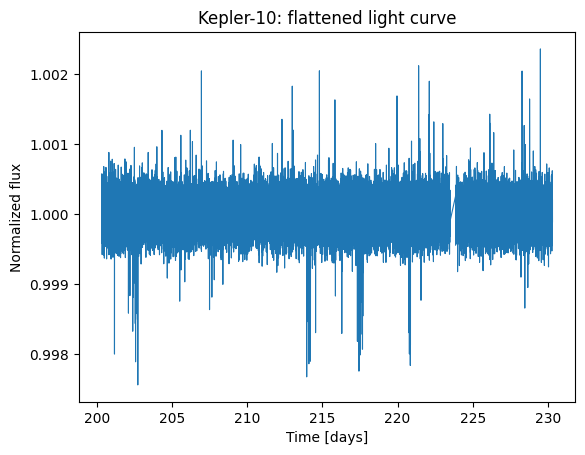

Cadences: 43354 Flux mean/std: 0.9999997871943874 0.00022496950256214673


In [ ]:
# Download, clean, flatten, and visualize a Kepler light curve for the target star Kepler-10.
target = "Kepler-10"
search = lk.search_lightcurve(target, mission="Kepler")
lc = search.download()

lc = lc.remove_nans().remove_outliers(sigma=10).normalize()
flat = lc.flatten(window_length=401, polyorder=2)

time = flat.time.value
flux = flat.flux.value

m = np.isfinite(time) & np.isfinite(flux)
time, flux = time[m], flux[m]

plt.figure()
plt.plot(time, flux, linewidth=0.8)
plt.xlabel("Time [days]")
plt.ylabel("Normalized flux")
plt.title(f"{target}: flattened light curve")
plt.show()

print("Cadences:", len(time), "Flux mean/std:", float(np.mean(flux)), float(np.std(flux)))


## 2. Transit injection and helper functions

In [ ]:
# Define functions to inject synthetic transit signals and evaluate their recovery using a transit-search algorithm.
def inject_box_transit(time, flux, period, depth_ppm, duration_hours, t0=None):
    """Inject a simple box transit into a flux array."""
    depth = depth_ppm / 1e6
    dur = duration_hours / 24.0
    if t0 is None:
        t0 = time.min() + rng.random() * period
    mod_flux = flux.copy()
    phase = ((time - t0) % period) / period
    intransit = (phase < dur/period) | (phase > 1 - dur/period)
    mod_flux[intransit] *= (1 - depth)
    return mod_flux

def box_in_transit_mask(time, period, duration_hours, t0):
    """Boolean mask for the same box model used in inject_box_transit."""
    dur = duration_hours / 24.0
    phase = ((time - t0) % period) / period
    return (phase < dur/period) | (phase > 1 - dur/period)

def recover_tls(time, flux, period_min=0.5, period_max=50, use_threads=1):
    """Run TLS and return the results object."""
    model = transitleastsquares(time, flux)
    res = model.power(period_min=period_min, period_max=period_max, use_threads=use_threads)
    return res


## 3. Single injection demo + TLS recovery

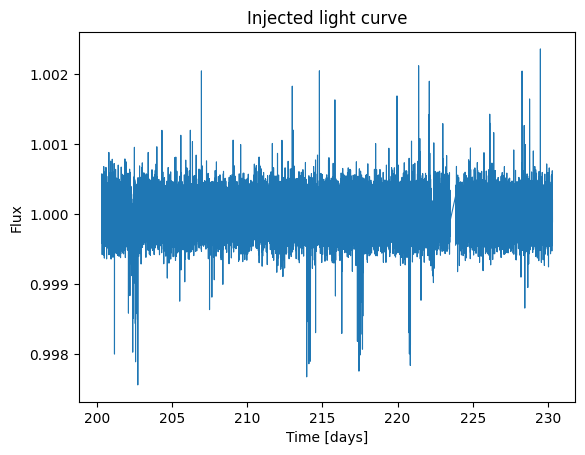

In-transit fraction: 0.021151450846519353


In [ ]:
# Inject a synthetic box-shaped transit into the light curve and visualize the resulting in-transit signal.
period_true = 10.0
duration_h_true = 2.5
depth_ppm_true = 300
t0_true = time.min() + 2.0

flux_inj = inject_box_transit(time, flux, period_true, depth_ppm_true, duration_h_true, t0=t0_true)
mask_in = box_in_transit_mask(time, period_true, duration_h_true, t0_true)

plt.figure()
plt.plot(time, flux_inj, linewidth=0.8)
plt.xlabel("Time [days]")
plt.ylabel("Flux")
plt.title("Injected light curve")
plt.show()

print("In-transit fraction:", float(mask_in.mean()))


Transit Least Squares TLS 1.32 (5 Apr 2024)
Creating model cache for 39 durations
Searching 43354 data points, 2781 periods from 0.601 to 14.988 days
Using all 8 CPU threads



  0%|          | 0/2781 periods | 00:00<?
  0%|          | 1/2781 periods | 00:02<2:17:51
  0%|          | 4/2781 periods | 00:03<27:30  
  0%|          | 8/2781 periods | 00:03<11:35
  0%|          | 11/2781 periods | 00:03<07:38
  1%|          | 15/2781 periods | 00:03<04:55
  1%|          | 20/2781 periods | 00:03<03:25
  1%|          | 25/2781 periods | 00:03<02:33
  1%|          | 29/2781 periods | 00:03<02:07
  1%|          | 33/2781 periods | 00:03<01:55
  1%|▏         | 37/2781 periods | 00:04<01:47
  2%|▏         | 44/2781 periods | 00:04<01:18
  2%|▏         | 52/2781 periods | 00:04<01:00
  2%|▏         | 58/2781 periods | 00:04<00:57
  2%|▏         | 68/2781 periods | 00:04<00:45
  3%|▎         | 78/2781 periods | 00:04<00:38
  3%|▎         | 87/2781 periods | 00:04<00:36
  4%|▎         | 98/2781 periods | 00:04<00:33
  4%|▍         | 108/2781 periods | 00:04<00:31
  4%|▍         | 117/2781 periods | 00:05<00:32
  5%|▍         | 128/2781 periods | 00:05<00:29
  5%|▍       

Searching for best T0 for period 9.99918 days
TLS best period: 9.99917670290914
TLS SDE: 14.19998475461377
TLS depth (ppm): 999685.525869491


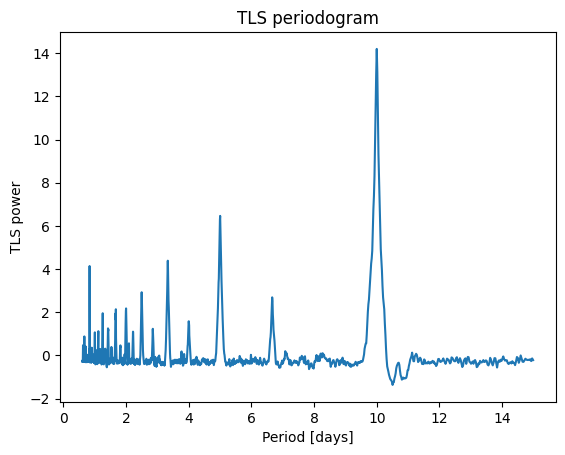

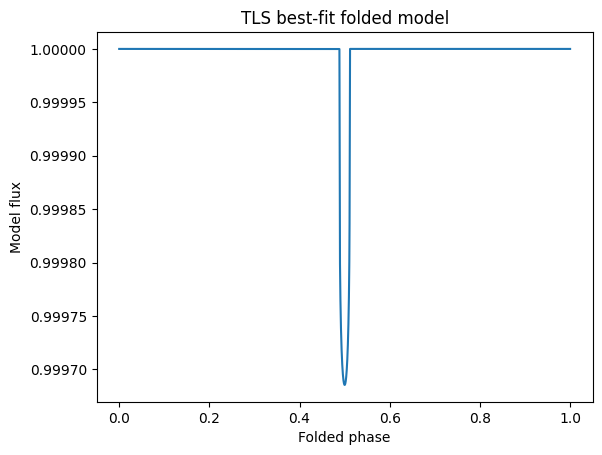

In [ ]:
# TLS recovery on injected light curve
res = recover_tls(time, flux_inj, period_min=0.5, period_max=20, use_threads=8)
print("TLS best period:", res.period)
print("TLS SDE:", res.SDE)
print("TLS depth (ppm):", res.depth * 1e6)

# Periodogram
plt.figure()
plt.plot(res.periods, res.power)
plt.xlabel("Period [days]")
plt.ylabel("TLS power")
plt.title("TLS periodogram")
plt.show()

# Folded model (TLS provides model_folded_phase and model_folded_model)
plt.figure()
plt.plot(res.model_folded_phase, res.model_folded_model)
plt.xlabel("Folded phase")
plt.ylabel("Model flux")
plt.title("TLS best-fit folded model")
plt.show()


## 4. Build a supervised window dataset for Keras

In [ ]:
# Create labeled, normalized fixed-length windows from the injected light curve for model training.
def make_windows(flux, mask_in, L=512, step=64):
    """Create fixed-length windows and labels from a flux series and in-transit mask.

    Returns:
      X: (N, L) float32
      y: (N,) int32
      starts: (N,) int32  (start cadence index for each window)
    """
    X, y, starts = [], [], []
    n = len(flux)
    for start in range(0, n - L + 1, step):
        end = start + L
        w = flux[start:end]
        if np.any(~np.isfinite(w)):
            continue
        X.append(w)
        y.append(1 if np.any(mask_in[start:end]) else 0)
        starts.append(start)
    return (np.array(X, dtype=np.float32),
            np.array(y, dtype=np.int32),
            np.array(starts, dtype=np.int32))

def normalize_windows(X):
    """Per-window standardisation."""
    mu = X.mean(axis=1, keepdims=True)
    sig = X.std(axis=1, keepdims=True) + 1e-8
    return (X - mu) / sig

L = 512
step = 64

X_raw, y, starts = make_windows(flux_inj, mask_in, L=L, step=step)
X = normalize_windows(X_raw)[..., None]  # (N, L, 1)

print("X shape:", X.shape, "y mean (pos frac):", float(y.mean()), "positives:", int(y.sum()))


X shape: (670, 512, 1) y mean (pos frac): 0.056716417910447764 positives: 38


In [ ]:
# Leakage-safe train/validation split:
# Split by time (cadence index), with a buffer of L cadences so train/val windows do not overlap.
#
# NOTE: This is for the single-light-curve demo only. For the multi-target dataset later,
# we will split by injection-run id ("sample_idx") which is even safer.

n_cad = len(flux_inj)
boundary = int(0.8 * n_cad)

# A window overlaps [start, start+L). To avoid overlap across the split:
# - training windows must end <= boundary
# - validation windows must start >= boundary + L
train_mask = (starts + L) <= boundary
val_mask = starts >= (boundary + L)

X_train, y_train = X[train_mask], y[train_mask]
X_val, y_val = X[val_mask], y[val_mask]

print("Train windows:", X_train.shape, "pos frac:", float(y_train.mean()), "positives:", int(y_train.sum()))
print("Val windows:  ", X_val.shape, "pos frac:", float(y_val.mean()), "positives:", int(y_val.sum()))


Train windows: (534, 512, 1) pos frac: 0.07116104868913857 positives: 38
Val windows:   (120, 512, 1) pos frac: 0.0 positives: 0


In [ ]:
# Build a baseline CNN model to classify fixed-length light-curve windows as transit or non-transit.
def make_baseline_cnn(seq_len: int) -> tf.keras.Model:
    inputs = tf.keras.Input(shape=(seq_len, 1))

    x = layers.Conv1D(32, 5, padding="same", activation="relu")(inputs)
    x = layers.MaxPool1D(2)(x)

    x = layers.Conv1D(64, 5, padding="same", activation="relu")(x)
    x = layers.MaxPool1D(2)(x)

    x = layers.Conv1D(128, 5, padding="same", activation="relu")(x)
    x = layers.GlobalAveragePooling1D()(x)

    x = layers.Dense(64, activation="relu")(x)
    x = layers.Dropout(0.3)(x)

    outputs = layers.Dense(1, activation="sigmoid")(x)

    model = tf.keras.Model(inputs, outputs, name="baseline_cnn")
    model.compile(
        optimizer=tf.keras.optimizers.Adam(1e-3),
        loss="binary_crossentropy",
        metrics=[
            "accuracy",
            tf.keras.metrics.AUC(name="auc"),
            tf.keras.metrics.Precision(name="precision"),
            tf.keras.metrics.Recall(name="recall"),
        ],
    )
    return model

model = make_baseline_cnn(X_train.shape[1])
model.summary()


Model: "baseline_cnn"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer (InputLayer)        │ (None, 512, 1)         │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv1d (Conv1D)                 │ (None, 512, 32)        │           192 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling1d (MaxPooling1D)    │ (None, 256, 32)        │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv1d_1 (Conv1D)               │ (None, 256, 64)        │        10,304 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling1d_1 (MaxPooling1D)  │ (None, 128, 64)        │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv1d_2 (Conv1D)               │ (None, 128, 128)       │        41,088 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling1d        │ (None, 128)            │             0 │
│ (GlobalAveragePooling1D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 64)             │         8,256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 1)              │            65 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 59,905 (234.00 KB)

 Trainable params: 59,905 (234.00 KB)

 Non-trainable params: 0 (0.00 B)

In [ ]:
# Compute class weights to address class imbalance and train the CNN using early stopping and learning-rate scheduling.
neg = int(np.sum(y_train == 0))
pos = int(np.sum(y_train == 1))
class_weight = None
if pos > 0:
    total = neg + pos
    class_weight = {0: total/(2*neg), 1: total/(2*pos)}

callbacks = [
    tf.keras.callbacks.EarlyStopping(monitor="val_auc", mode="max", patience=5, restore_best_weights=True),
    tf.keras.callbacks.ReduceLROnPlateau(monitor="val_auc", mode="max", factor=0.5, patience=2, min_lr=1e-6),
]

history = model.fit(
    X_train, y_train,
    validation_data=(X_val, y_val),
    epochs=20,
    batch_size=64,
    class_weight=class_weight,
    callbacks=callbacks,
    verbose=1
)


Epoch 1/20
9/9 ━━━━━━━━━━━━━━━━━━━━ 12s 569ms/step - accuracy: 0.6654 - auc: 0.5231 - loss: 0.6611 - precision: 0.0556 - recall: 0.2956 - val_accuracy: 1.0000 - val_auc: 0.0000e+00 - val_loss: 0.6586 - val_precision: 0.0000e+00 - val_recall: 0.0000e+00 - learning_rate: 0.0010
Epoch 2/20
9/9 ━━━━━━━━━━━━━━━━━━━━ 0s 17ms/step - accuracy: 0.8568 - auc: 0.7685 - loss: 0.6474 - precision: 0.1736 - recall: 0.2614 - val_accuracy: 1.0000 - val_auc: 0.0000e+00 - val_loss: 0.6105 - val_precision: 0.0000e+00 - val_recall: 0.0000e+00 - learning_rate: 0.0010
Epoch 3/20
9/9 ━━━━━━━━━━━━━━━━━━━━ 0s 16ms/step - accuracy: 0.8069 - auc: 0.8355 - loss: 0.6376 - precision: 0.2150 - recall: 0.6426 - val_accuracy: 1.0000 - val_auc: 0.0000e+00 - val_loss: 0.5162 - val_precision: 0.0000e+00 - val_recall: 0.0000e+00 - learning_rate: 0.0010
Epoch 4/20
9/9 ━━━━━━━━━━━━━━━━━━━━ 0s 16ms/step - accuracy: 0.8740 - auc: 0.8831 - loss: 0.6444 - precision: 0.4378 - recall: 0.7041 - val_accuracy: 1.0000 - val_auc: 0.000

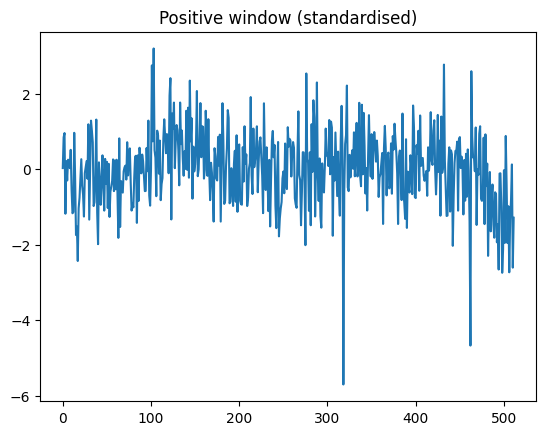

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 480ms/step
Pred prob (positive): 0.48698505759239197


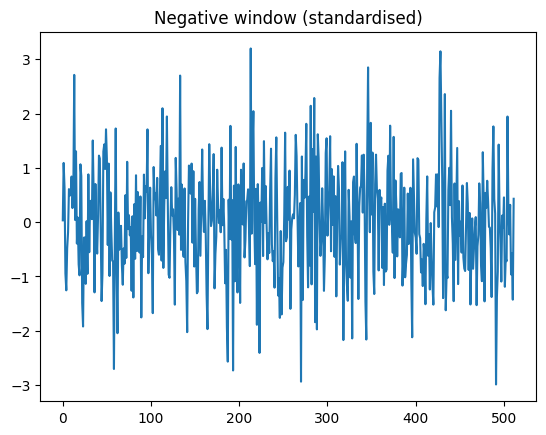

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 28ms/step
Pred prob (negative): 0.4771856665611267


In [ ]:
# Sanity-check: plot one positive and one negative window + model scores
pos_idx = np.where(y_train == 1)[0]
neg_idx = np.where(y_train == 0)[0]

if len(pos_idx) > 0:
    i = pos_idx[0]
    plt.figure(); plt.plot(X_train[i,:,0]); plt.title("Positive window (standardised)"); plt.show()
    print("Pred prob (positive):", float(model.predict(X_train[i:i+1]).ravel()[0]))

j = neg_idx[0]
plt.figure(); plt.plot(X_train[j,:,0]); plt.title("Negative window (standardised)"); plt.show()
print("Pred prob (negative):", float(model.predict(X_train[j:j+1]).ravel()[0]))


## 5. Baseline Keras model (purely data-driven)

In [ ]:
# --- injector (matches mask exactly) ---
def inject_box_transit(time, flux, period, depth_ppm, duration_hours, t0=None, rng=None):
    if rng is None:
        rng = np.random.default_rng(42)

    depth = depth_ppm / 1e6
    dur = duration_hours / 24.0
    if t0 is None:
        t0 = float(time.min() + rng.random() * period)

    mod_flux = flux.copy()
    phase = ((time - t0) % period) / period
    intransit = (phase < dur / period) | (phase > 1 - dur / period)
    mod_flux[intransit] *= (1 - depth)
    return mod_flux

def box_in_transit_mask(time, period, duration_hours, t0):
    dur = duration_hours / 24.0
    phase = ((time - t0) % period) / period
    return (phase < dur / period) | (phase > 1 - dur / period)

def estimate_sigma_out_of_transit(flux, in_transit_mask):
    oot = flux[~in_transit_mask]
    return float(np.std(oot))

# ----------------------------
# labeling + window extraction
# ----------------------------
def label_windows(mask_in_transit_window, mode="any", frac_threshold=0.05):
    if mode == "any":
        return int(mask_in_transit_window.any())
    elif mode == "center":
        return int(mask_in_transit_window[len(mask_in_transit_window)//2])
    elif mode == "frac":
        return int(mask_in_transit_window.mean() >= frac_threshold)
    else:
        raise ValueError(f"Unknown label mode: {mode}")

def make_windows_with_mode(flux, mask_in_transit, L=512, step=64, label_mode="any", frac_threshold=0.05):
    X, y, starts = [], [], []
    n = len(flux)

    for s in range(0, n - L + 1, step):
        w = flux[s:s+L]
        m = mask_in_transit[s:s+L]
        if np.any(~np.isfinite(w)):
            continue
        X.append(w)
        y.append(label_windows(m, mode=label_mode, frac_threshold=frac_threshold))
        starts.append(s)

    return (np.array(X, dtype=np.float32),
            np.array(y, dtype=np.int32),
            np.array(starts, dtype=np.int32))

def normalize_windows(X):
    mu = X.mean(axis=1, keepdims=True)
    sig = X.std(axis=1, keepdims=True) + 1e-8
    return (X - mu) / sig

# --------------------------------------------
# one injection-run (or negative-only run) builder
# --------------------------------------------
def build_kepler_injection_dataset_one(
    target,
    period_true,
    duration_hours,
    snr_target,
    L=512,
    step=64,
    t0=None,
    rng_seed=42,
    preprocess_kwargs=None,
    label_mode="any",
    frac_threshold=0.05,
    inject=True,
    # NEW: allow passing preprocessed arrays
    time=None,
    base_flux=None,
):
    if preprocess_kwargs is None:
        preprocess_kwargs = {}

    rng = np.random.default_rng(rng_seed)

    # NEW: load & preprocess only if not provided (cache hook)
    if time is None or base_flux is None:
        time, base_flux = preprocess_kepler_lightcurve(target, **preprocess_kwargs)

    # set t0
    if t0 is None:
        t0 = float(time.min() + rng.random() * period_true)

    # mask on the injected ephemeris
    mask_in = box_in_transit_mask(time, period_true, duration_hours, t0)

    # sigma from OOT
    sigma = estimate_sigma_out_of_transit(base_flux, mask_in)

    # SNR -> depth
    depth_rel = snr_target * sigma
    depth_ppm = float(depth_rel * 1e6)

    # inject or not
    if inject:
        flux_use = inject_box_transit(time, base_flux, period_true, depth_ppm, duration_hours, t0=t0, rng=rng)
        y_mask = mask_in
    else:
        flux_use = base_flux.copy()
        y_mask = np.zeros_like(mask_in, dtype=bool)

    in_frac = float(mask_in.mean())

    Xw, yw, starts = make_windows_with_mode(
        flux_use, y_mask, L=L, step=step, label_mode=label_mode, frac_threshold=frac_threshold
    )

    Xw = normalize_windows(Xw)[..., None]  # float32 already from make_windows_with_mode

    meta = {
        "target": target,
        "period_true_days": float(period_true),
        "duration_hours": float(duration_hours),
        "snr_target": float(snr_target),
        "sigma_flux": float(sigma),
        "depth_ppm": float(depth_ppm),
        "t0": float(t0),
        "in_transit_fraction": float(in_frac),
        "n_windows": int(len(yw)),
        "n_positive_windows": int(yw.sum()),
        "L": int(L),
        "step": int(step),
        "label_mode": str(label_mode),
        "frac_threshold": float(frac_threshold),
        "inject": bool(inject),
        "rng_seed": int(rng_seed),
    }

    return Xw, yw, starts, meta


# -------------------------
# dataset: many targets/runs
# -------------------------
def build_dataset_many(
    targets,
    n_injections_per_target=15,
    period_sampler=None,
    duration_sampler=None,
    snr_sampler=None,
    L=512,
    step=64,
    rng_seed=123,
    preprocess_kwargs=None,
    label_mode="any",
    frac_threshold=0.05,
    add_negative_fraction=0.25,
):
    if preprocess_kwargs is None:
        preprocess_kwargs = {}

    rng = np.random.default_rng(rng_seed)

    if period_sampler is None:
        period_sampler = lambda r: float(r.uniform(1.0, 20.0))
    if duration_sampler is None:
        duration_sampler = lambda r: float(r.uniform(1.0, 10.0))
    if snr_sampler is None:
        snr_sampler = lambda r: float(r.uniform(2.0, 8.0))

    X_all, y_all = [], []
    target_idx_all, sample_idx_all, start_idx_all = [], [], []
    sample_meta = []
    global_sample_idx = 0

    for ti, target in enumerate(targets):
        # NEW: preprocess ONCE per target
        t_arr, f_arr = preprocess_kepler_lightcurve(target, **preprocess_kwargs)

        # injected runs
        for _ in range(n_injections_per_target):
            period = period_sampler(rng)
            duration = duration_sampler(rng)
            snr = snr_sampler(rng)
            seed_k = int(rng.integers(0, 2**31 - 1))

            Xw, yw, starts, meta = build_kepler_injection_dataset_one(
                target=target,
                period_true=period,
                duration_hours=duration,
                snr_target=snr,
                L=L,
                step=step,
                t0=None,
                rng_seed=seed_k,
                preprocess_kwargs=preprocess_kwargs,
                label_mode=label_mode,
                frac_threshold=frac_threshold,
                inject=True,
                # NEW: reuse cached arrays
                time=t_arr,
                base_flux=f_arr,
            )

            X_all.append(Xw); y_all.append(yw)
            target_idx_all.append(np.full(len(yw), ti, dtype=np.int32))
            sample_idx_all.append(np.full(len(yw), global_sample_idx, dtype=np.int32))
            start_idx_all.append(starts.astype(np.int32))

            sample_meta.append(meta)
            global_sample_idx += 1

        # negative-only runs
        n_neg = int(np.round(n_injections_per_target * add_negative_fraction))
        for _ in range(n_neg):
            period = period_sampler(rng)
            duration = duration_sampler(rng)
            snr = snr_sampler(rng)
            seed_k = int(rng.integers(0, 2**31 - 1))

            Xw, yw, starts, meta = build_kepler_injection_dataset_one(
                target=target,
                period_true=period,
                duration_hours=duration,
                snr_target=snr,
                L=L,
                step=step,
                t0=None,
                rng_seed=seed_k,
                preprocess_kwargs=preprocess_kwargs,
                label_mode=label_mode,
                frac_threshold=frac_threshold,
                inject=False,
                # NEW: reuse cached arrays
                time=t_arr,
                base_flux=f_arr,
            )

            X_all.append(Xw); y_all.append(yw)
            target_idx_all.append(np.full(len(yw), ti, dtype=np.int32))
            sample_idx_all.append(np.full(len(yw), global_sample_idx, dtype=np.int32))
            start_idx_all.append(starts.astype(np.int32))

            sample_meta.append(meta)
            global_sample_idx += 1

    X = np.concatenate(X_all, axis=0)
    y = np.concatenate(y_all, axis=0)

    win_info = {
        "target_idx": np.concatenate(target_idx_all, axis=0),
        "sample_idx": np.concatenate(sample_idx_all, axis=0),
        "start_idx": np.concatenate(start_idx_all, axis=0),
        "targets": list(targets),
    }

    return X, y, sample_meta, win_info

# -------------------------
# leakage-safe split utilities
# -------------------------
def split_by_group(group_ids, train_frac=0.7, val_frac=0.15, rng_seed=0):
    """Return boolean masks (train, val, test) splitting by unique group id."""
    assert 0 < train_frac < 1 and 0 < val_frac < 1 and (train_frac + val_frac) < 1
    rng = np.random.default_rng(rng_seed)

    groups = np.unique(group_ids)
    rng.shuffle(groups)

    n = len(groups)
    n_train = int(np.floor(train_frac * n))
    n_val = int(np.floor(val_frac * n))

    g_train = set(groups[:n_train])
    g_val = set(groups[n_train:n_train+n_val])
    g_test = set(groups[n_train+n_val:])

    train_mask = np.array([g in g_train for g in group_ids], dtype=bool)
    val_mask = np.array([g in g_val for g in group_ids], dtype=bool)
    test_mask = np.array([g in g_test for g in group_ids], dtype=bool)
    return train_mask, val_mask, test_mask

def save_dataset_npz(path_prefix, X, y, sample_meta, win_info):
    np.savez_compressed(
        f"{path_prefix}.npz",
        X=X.astype(np.float32),
        y=y.astype(np.int32),
        target_idx=win_info["target_idx"].astype(np.int32),
        sample_idx=win_info["sample_idx"].astype(np.int32),
        start_idx=win_info["start_idx"].astype(np.int32),
    )

    payload = {
        "targets": win_info["targets"],
        "n_windows": int(len(y)),
        "n_positive_windows": int(y.sum()),
        "sample_meta": sample_meta,
        "win_info_fields": ["target_idx", "sample_idx", "start_idx"],
    }
    with open(f"{path_prefix}.json", "w", encoding="utf-8") as f:
        json.dump(payload, f, indent=2)


In [ ]:
# Download, preprocess, and flatten Kepler light curves for a target star with safeguards to limit data volume and runtime.
def preprocess_kepler_lightcurve(
    target,
    window_length=401,
    polyorder=2,
    sigma_clip=10,
    max_lcs=5,              # <= key change: limit how many files you download
    min_cadences=8000,      # stop criterion for “enough data”
):
    """
    Download + normalize + flatten a Kepler light curve, but bounded so it doesn't stall.

    max_lcs: number of LC files to download (typically 1–3 is enough for dataset building).
    """
    search = lk.search_lightcurve(target, mission="Kepler")
    if len(search) == 0:
        raise ValueError(f"No Kepler light curves found for {target}")

    # Download only the first max_lcs products
    n = min(max_lcs, len(search))
    lcs = search[:n].download_all()
    lc = lcs.stitch() if hasattr(lcs, "stitch") else lcs[0]

    lc = lc.remove_nans().remove_outliers(sigma=sigma_clip).normalize()
    flat = lc.flatten(window_length=window_length, polyorder=polyorder)

    time = flat.time.value
    flux = flat.flux.value

    m = np.isfinite(time) & np.isfinite(flux)
    time, flux = time[m], flux[m]

    # If still too short and more products exist, progressively add more (bounded)
    # This avoids "download_all" while still trying to reach min_cadences.
    if len(time) < min_cadences and n < len(search):
        # Try adding up to 3 total by default
        n2 = min(max(3, max_lcs), len(search))
        lcs = search[:n2].download_all()
        lc = lcs.stitch()
        lc = lc.remove_nans().remove_outliers(sigma=sigma_clip).normalize()
        flat = lc.flatten(window_length=window_length, polyorder=polyorder)

        time = flat.time.value
        flux = flat.flux.value
        m = np.isfinite(time) & np.isfinite(flux)
        time, flux = time[m], flux[m]

    return time, flux


In [ ]:
# Build a dataset from 50 Kepler mission targets

candidate_targets = [
    # Original list
    "Kepler-10", "Kepler-11", "Kepler-12", "Kepler-13", "Kepler-14",
    "Kepler-15", "Kepler-16", "Kepler-17", "Kepler-18", "Kepler-19",
    "Kepler-20", "Kepler-21", "Kepler-22", "Kepler-25", "Kepler-37",
    "KIC 757450", "KIC 11446443", "KIC 8462852", "KIC 12066335", "KIC 6922244",

    # Additional confirmed Kepler planets
    "Kepler-4", "Kepler-5", "Kepler-6", "Kepler-7", "Kepler-8", "Kepler-9",
    "Kepler-30", "Kepler-32", "Kepler-36", "Kepler-38", "Kepler-42",
    "Kepler-44", "Kepler-45", "Kepler-49", "Kepler-51", "Kepler-56",
    "Kepler-62", "Kepler-68", "Kepler-78", "Kepler-90", "Kepler-91",
    "Kepler-93", "Kepler-94", "Kepler-100", "Kepler-102", "Kepler-104",
    "Kepler-108", "Kepler-111", "Kepler-138", "Kepler-148", "Kepler-167",
    "Kepler-186", "Kepler-444",

    # Known interesting KICs (good LC coverage)
    "KIC 6106415", "KIC 6116048", "KIC 6525196", "KIC 6603624",
    "KIC 7289157", "KIC 7428725", "KIC 8008067", "KIC 9025370",
    "KIC 10068307", "KIC 10593626", "KIC 10748390",
    "KIC 11026764", "KIC 11244118", "KIC 11853905",
]

targets_ok = []
lc_cache = {}
fail_log = []

N_TARGETS = 30

for t in candidate_targets:
    try:
        time, flux = preprocess_kepler_lightcurve(t, window_length=401, polyorder=2, sigma_clip=10)
        if len(time) > 2000:
            targets_ok.append(t)
            lc_cache[t] = (time, flux)   # <-- keep it
            print(f"[OK {len(targets_ok):02d}] {t}  n={len(time)}")
        else:
            fail_log.append((t, "TooShort", f"n={len(time)}"))
            print(f"[FAIL] {t} -> TooShort (n={len(time)})")

        if len(targets_ok) >= N_TARGETS:
            break

    except Exception as e:
        fail_log.append((t, type(e).__name__, str(e)))
        print(f"[FAIL] {t} -> {type(e).__name__}: {str(e)[:200]}")


[OK 01] Kepler-10  n=168887
[FAIL] Kepler-11 -> LightkurveError: Not recognized as a supported data product:
/root/.lightkurve/cache/mastDownload/Kepler/kplr006541920_sc_Q000333333333333332/kplr006541920-2009291181958_slc.fits
This file may be corrupt due to an int


 11%|█         | 301/2781 periods | 03:54<32:10


[OK 02] Kepler-12  n=210514
[OK 03] Kepler-13  n=210517
[OK 04] Kepler-14  n=127154
[OK 05] Kepler-15  n=130767
[OK 06] Kepler-16  n=53259
[OK 07] Kepler-17  n=95679
[OK 08] Kepler-18  n=127149
[OK 09] Kepler-19  n=127141
[OK 10] Kepler-20  n=130750
[OK 11] Kepler-21  n=48568
[OK 12] Kepler-22  n=163790
[OK 13] Kepler-25  n=54813
[OK 14] Kepler-37  n=51068
[OK 15] KIC 757450  n=18420
[OK 16] KIC 11446443  n=186179
[OK 17] KIC 8462852  n=14386
[OK 18] KIC 12066335  n=18420
[OK 19] KIC 6922244  n=210502
[OK 20] Kepler-4  n=210482
[OK 21] Kepler-5  n=204538
[OK 22] Kepler-6  n=210511
[OK 23] Kepler-7  n=127165
[OK 24] Kepler-8  n=204532
[OK 25] Kepler-9  n=94629
[OK 26] Kepler-30  n=94629
[OK 27] Kepler-32  n=18421
[OK 28] Kepler-36  n=49924
[OK 29] Kepler-38  n=18422
[OK 30] Kepler-42  n=18415


In [ ]:
# Build a multi-target dataset by injecting synthetic transits into Kepler light curves and extracting labeled training windows.
X_ds, y_ds, sample_meta, win_info = build_dataset_many(
    targets_ok,
    n_injections_per_target=15,
    L=512,
    step=64,
    rng_seed=2025,
    preprocess_kwargs=dict(window_length=401, polyorder=2, sigma_clip=10),
    label_mode="any",
    add_negative_fraction=0.33,
)

print("Dataset X:", X_ds.shape, "y pos frac:", float(y_ds.mean()), "positives:", int(y_ds.sum()))

Dataset X: (1057820, 512, 1) y pos frac: 0.12787714355939575 positives: 135271


In [ ]:
# Leakage-safe split by injection-run id ("sample_idx")
train_mask, val_mask, test_mask = split_by_group(
    win_info["target_idx"],
    train_frac=0.7,
    val_frac=0.15,
    rng_seed=2025,
)

X_train, y_train = X_ds[train_mask], y_ds[train_mask]
X_val, y_val = X_ds[val_mask], y_ds[val_mask]
X_test, y_test = X_ds[test_mask], y_ds[test_mask]

print("Train:", X_train.shape, "pos frac:", float(y_train.mean()))
print("Val:  ", X_val.shape, "pos frac:", float(y_val.mean()))
print("Test: ", X_test.shape, "pos frac:", float(y_test.mean()))

# Save to disk for reuse / thesis reproducibility
save_dataset_npz("kepler_injection_dataset_25targets_v1", X_ds, y_ds, sample_meta, win_info)
print("Saved kepler_injection_dataset_25targets_v1.npz and .json")

Train: (761260, 512, 1) pos frac: 0.12894805979560203
Val:   (137240, 512, 1) pos frac: 0.1341664237831536
Test:  (159320, 512, 1) pos frac: 0.1173424554356013
Saved kepler_injection_dataset_25targets_v1.npz and .json


In [ ]:
#Load data
path_prefix = "/content/kepler_injection_dataset_25targets_v1"

data = np.load(f"{path_prefix}.npz")

X_ds = data["X"]              # shape: (N, L, 1)
y_ds = data["y"]              # shape: (N,)
target_idx = data["target_idx"]
sample_idx = data["sample_idx"]
start_idx  = data["start_idx"]

print("X:", X_ds.shape, X_ds.dtype)
print("y:", y_ds.shape, "pos frac:", y_ds.mean())

with open(f"{path_prefix}.json", "r") as f:
    meta = json.load(f)

targets = meta["targets"]
sample_meta = meta["sample_meta"]

print("Targets:", len(targets))
print("Total windows:", meta["n_windows"])
print("Positive windows:", meta["n_positive_windows"])



X: (1057820, 512, 1) float32
y: (1057820,) pos frac: 0.12787714355939575
Targets: 30
Total windows: 1057820
Positive windows: 135271


In [ ]:
# Store window-level metadata linking each sample to its target star and original light-curve indices.
win_info = {
    "target_idx": target_idx,
    "sample_idx": sample_idx,
    "start_idx": start_idx,
    "targets": targets,
}


In [ ]:
# Perform basic sanity checks to confirm the dataset is well-formed and valid.
print("X:", X_ds.shape, X_ds.dtype)
print("y:", y_ds.shape, y_ds.dtype)
print("pos frac:", float(y_ds.mean()), "n_pos:", int(y_ds.sum()))

assert X_ds.ndim == 3 and X_ds.shape[-1] == 1
assert len(X_ds) == len(y_ds)
assert np.isfinite(X_ds).all()
assert set(np.unique(y_ds)).issubset({0, 1})


X: (1057820, 512, 1) float32
y: (1057820,) int32
pos frac: 0.12787714355939575 n_pos: 135271


In [ ]:
# Quick sanity check
for k in ["target_idx", "sample_idx", "start_idx", "targets"]:
    print(k, "OK" if k in win_info else "MISSING")


target_idx OK
sample_idx OK
start_idx OK
targets OK


In [ ]:
# Create leakage-safe train, validation, and test splits based on injection sample identifiers.
rng = np.random.default_rng(2025)

sample_ids = np.unique(win_info["sample_idx"])
rng.shuffle(sample_ids)

n = len(sample_ids)
train_ids = set(sample_ids[: int(0.7*n)])
val_ids   = set(sample_ids[int(0.7*n): int(0.85*n)])
test_ids  = set(sample_ids[int(0.85*n):])

sid = win_info["sample_idx"]
train_m = np.array([s in train_ids for s in sid])
val_m   = np.array([s in val_ids for s in sid])
test_m  = np.array([s in test_ids for s in sid])

X_tr, y_tr = X_ds[train_m], y_ds[train_m]
X_va, y_va = X_ds[val_m],   y_ds[val_m]
X_te, y_te = X_ds[test_m],  y_ds[test_m]

print("Train:", X_tr.shape, "pos:", float(y_tr.mean()))
print("Val:  ", X_va.shape, "pos:", float(y_va.mean()))
print("Test: ", X_te.shape, "pos:", float(y_te.mean()))


Train: (735875, 512, 1) pos: 0.13280108714115849
Val:   (154804, 512, 1) pos: 0.12284566290276737
Test:  (167141, 512, 1) pos: 0.11085849671833961


In [ ]:
# Evaluate a simple rule-based detector and tune its threshold on the validation set using the F1 score.
def minflux_baseline(X):
    return X[:, :, 0].min(axis=1)

s_tr = minflux_baseline(X_tr)
s_va = minflux_baseline(X_va)

# choose threshold on validation to maximize F1 (simple grid)
ths = np.linspace(s_tr.min(), s_tr.max(), 200)
best = None

for th in ths:
    yhat = (s_va < th).astype(int)
    tp = ((yhat==1) & (y_va==1)).sum()
    fp = ((yhat==1) & (y_va==0)).sum()
    fn = ((yhat==0) & (y_va==1)).sum()
    f1 = (2*tp)/(2*tp+fp+fn+1e-9)
    if best is None or f1 > best[0]:
        best = (f1, th)

print("Best val F1:", best[0], "th:", best[1])


Best val F1: 0.3025355208415024 th: -4.089344


In [ ]:
pos = y_tr.sum()
neg = len(y_tr) - pos

class_weight = {
    0: 1.0,
    1: float(neg / pos),
}

class_weight


{0: 1.0, 1: 6.5300588385776415}

In [ ]:
# Train the baseline CNN with PR-AUC–based early stopping and evaluate performance using multiple classification metrics.
callbacks = [
    tf.keras.callbacks.EarlyStopping(
        monitor="val_pr_auc",
        mode="max",
        patience=5,
        min_delta=1e-3,
        restore_best_weights=True,
    ),
]

model = make_baseline_cnn(X_tr.shape[1])

model.compile(
    optimizer=tf.keras.optimizers.Adam(1e-3),
    loss="binary_crossentropy",
    metrics=[
        tf.keras.metrics.AUC(name="pr_auc", curve="PR"),
        tf.keras.metrics.AUC(name="roc_auc"),
        tf.keras.metrics.Precision(name="precision"),
        tf.keras.metrics.Recall(name="recall"),
        "accuracy",
    ],
)


history = model.fit(
    X_tr, y_tr,
    validation_data=(X_va, y_va),
    epochs=50,
    batch_size=256,
    class_weight=class_weight,
    callbacks=callbacks,
    verbose=2,
)


Epoch 1/50
2875/2875 - 75s - 26ms/step - accuracy: 0.9327 - loss: 0.5051 - pr_auc: 0.8487 - precision: 0.7036 - recall: 0.8519 - roc_auc: 0.9265 - val_accuracy: 0.9705 - val_loss: 0.1695 - val_pr_auc: 0.9117 - val_precision: 0.8795 - val_recall: 0.8804 - val_roc_auc: 0.9439
Epoch 2/50
2875/2875 - 63s - 22ms/step - accuracy: 0.9666 - loss: 0.4022 - pr_auc: 0.8993 - precision: 0.8824 - recall: 0.8640 - roc_auc: 0.9373 - val_accuracy: 0.9751 - val_loss: 0.1502 - val_pr_auc: 0.9170 - val_precision: 0.9104 - val_recall: 0.8842 - val_roc_auc: 0.9453
Epoch 3/50
2875/2875 - 62s - 22ms/step - accuracy: 0.9718 - loss: 0.3825 - pr_auc: 0.9064 - precision: 0.9164 - recall: 0.8668 - roc_auc: 0.9403 - val_accuracy: 0.9716 - val_loss: 0.1578 - val_pr_auc: 0.9175 - val_precision: 0.8799 - val_recall: 0.8905 - val_roc_auc: 0.9456
Epoch 4/50
2875/2875 - 62s - 22ms/step - accuracy: 0.9741 - loss: 0.3706 - pr_auc: 0.9100 - precision: 0.9316 - recall: 0.8691 - roc_auc: 0.9432 - val_accuracy: 0.9806 - val_l

In [ ]:
# Identify and report the training epoch with the highest validation PR-AUC.
vals = history.history["val_pr_auc"]
best_epoch = np.argmax(vals) + 1
best_val = np.max(vals)

print("Best epoch:", best_epoch)
print("Best val PR-AUC:", best_val)


Best epoch: 6
Best val PR-AUC: 0.9226831197738647


In [ ]:
# Evaluate the trained CNN on the held-out test set and report final performance metrics.
test_metrics = model.evaluate(X_te, y_te, verbose=0)
for name, val in zip(model.metrics_names, test_metrics):
    print(f"{name}: {val:.4f}")


loss: 0.1298
compile_metrics: 0.9145


In [ ]:
y_val_prob = model.predict(X_va, batch_size=256).ravel()


605/605 ━━━━━━━━━━━━━━━━━━━━ 2s 3ms/step


In [ ]:
# Tune the decision threshold on the validation set by maximizing the F1 score.
ths = np.linspace(0.01, 0.99, 200)
best = (0, 0)

for th in ths:
    yhat = (y_val_prob >= th).astype(int)
    tp = ((yhat == 1) & (y_va == 1)).sum()
    fp = ((yhat == 1) & (y_va == 0)).sum()
    fn = ((yhat == 0) & (y_va == 1)).sum()
    f1 = 2*tp / (2*tp + fp + fn + 1e-9)
    if f1 > best[0]:
        best = (f1, th)

best_f1, best_th = best
print("Best val F1:", best_f1)
print("Chosen threshold:", best_th)


Best val F1: 0.9290896455871877
Chosen threshold: 0.7782412060301508


In [ ]:
[(k, getattr(v, "shape", None)) for k, v in globals().items()
 if k.lower() in ["y_te", "y_test", "y_te_w", "y_test_w", "y_test_true"]
 or (k.lower().startswith("y_") and "te" in k.lower() and hasattr(v, "__len__"))]


[('y_test', (159320,)), ('y_te', (167141,))]

In [ ]:
# Apply the selected decision threshold to the test set and compute final classification performance metrics.
y_test_prob = model.predict(X_te, batch_size=256).ravel()
y_test_hat = (y_test_prob >= best_th).astype(int)

tp = ((y_test_hat == 1) & (y_te == 1)).sum()
fp = ((y_test_hat == 1) & (y_te == 0)).sum()
tn = ((y_test_hat == 0) & (y_te == 0)).sum()
fn = ((y_test_hat == 0) & (y_te == 1)).sum()

precision = tp / (tp + fp + 1e-9)
recall    = tp / (tp + fn + 1e-9)
f1        = 2*precision*recall / (precision + recall + 1e-9)
accuracy  = (tp + tn) / (tp + tn + fp + fn + 1e-9)

print("Test precision:", precision)
print("Test recall:", recall)
print("Test F1:", f1)
print("Test accuracy:", accuracy)


653/653 ━━━━━━━━━━━━━━━━━━━━ 2s 3ms/step
Test precision: 0.9809026711697278
Test recall: 0.862108046845439
Test F1: 0.9176767961930109
Test accuracy: 0.9828528009285515


In [ ]:
# Evaluate the CNN’s test-set performance using PR-AUC and ROC-AUC metrics.
pr_auc_cnn  = average_precision_score(y_te, y_test_prob)
roc_auc_cnn = roc_auc_score(y_te, y_test_prob)

print("CNN WINDOW-LEVEL TEST PR-AUC :", pr_auc_cnn)
print("CNN WINDOW-LEVEL TEST ROC-AUC:", roc_auc_cnn)


CNN WINDOW-LEVEL TEST PR-AUC : 0.9167577482246014
CNN WINDOW-LEVEL TEST ROC-AUC: 0.9458875368472109


## 5. Physics-Integrated Keras model

In [ ]:
# Partition window metadata to match the train, validation, and test data splits.
def slice_win_info(win_info, mask):
    return {
        "target_idx": win_info["target_idx"][mask],
        "sample_idx": win_info["sample_idx"][mask],
        "start_idx":  win_info["start_idx"][mask],
        "targets":    win_info["targets"],  # keep full list
    }

win_tr = slice_win_info(win_info, train_m)
win_va = slice_win_info(win_info, val_m)
win_te = slice_win_info(win_info, test_m)

print("Split lens:", len(win_tr["sample_idx"]), len(win_va["sample_idx"]), len(win_te["sample_idx"]))
print("X lens:", len(X_tr), len(X_va), len(X_te))
assert len(win_tr["sample_idx"]) == len(X_tr)
assert len(win_va["sample_idx"]) == len(X_va)
assert len(win_te["sample_idx"]) == len(X_te)


Split lens: 735875 154804 167141
X lens: 735875 154804 167141


In [ ]:
p_tr = model.predict(X_tr, batch_size=256).ravel()
p_va = model.predict(X_va, batch_size=256).ravel()
p_te = model.predict(X_te, batch_size=256).ravel()


2875/2875 ━━━━━━━━━━━━━━━━━━━━ 7s 2ms/step
605/605 ━━━━━━━━━━━━━━━━━━━━ 2s 3ms/step
653/653 ━━━━━━━━━━━━━━━━━━━━ 2s 2ms/step


In [ ]:
# Must match your dataset build kwargs
preprocess_kwargs = dict(window_length=401, polyorder=2, sigma_clip=10, max_lcs=5, min_cadences=8000)

targets = win_info["targets"]

time_cache = {}
for t in targets:
    time, flux = preprocess_kepler_lightcurve(t, **preprocess_kwargs)
    time_cache[t] = time


In [ ]:
# Estimate candidate transit event times from high-confidence window predictions using the minimum-flux location.
def window_event_times(X, p, starts, target_idx, time_cache, targets, p_gate=0.9):
    """
    For windows with p >= p_gate, return an estimated event time using argmin flux index.
    """
    keep = p >= p_gate
    if keep.sum() == 0:
        return np.array([], dtype=float)

    Xk = X[keep, :, 0]
    sk = starts[keep]
    tk = target_idx[keep]

    # argmin index within window as "event center" proxy
    j = np.argmin(Xk, axis=1)

    t_events = []
    for s, jj, ti in zip(sk, j, tk):
        tarr = time_cache[targets[int(ti)]]
        idx = int(s + jj)
        if 0 <= idx < len(tarr):
            t_events.append(float(tarr[idx]))

    return np.array(t_events, dtype=float)


In [ ]:
def score_three_transits(times, tau=0.02,  # days; ~30 min is 0.0208 d
                         P_min=0.5, P_max=30.0):
    """
    Return a candidate score in [0,1] and the best-fit period (or None).
    times: array of event times (days)
    tau: alignment tolerance in days (TTV allowance)
    """
    times = np.sort(np.unique(times))
    n = len(times)
    if n < 3:
        return 0.0, None

    # Candidate periods from pairwise differences (simple, robust)
    dts = []
    for i in range(n):
        for j in range(i+1, n):
            d = times[j] - times[i]
            if d <= 0:
                continue
            # allow harmonics: P = d/k
            for k in (1, 2, 3, 4, 5):
                P = d / k
                if P_min <= P <= P_max:
                    dts.append(P)

    if len(dts) == 0:
        return 0.0, None

    # Evaluate candidate periods by counting alignments modulo P
    best_count = 0
    best_P = None

    for P in dts:
        # compute phases in [0, P)
        phases = (times - times[0]) % P
        phases = np.sort(phases)

        # Cluster phases within tau: if many events have similar phase => periodic
        # simple clustering
        count = 1
        max_cluster = 1
        for i in range(1, len(phases)):
            if abs(phases[i] - phases[i-1]) <= tau:
                count += 1
            else:
                max_cluster = max(max_cluster, count)
                count = 1
        max_cluster = max(max_cluster, count)

        if max_cluster > best_count:
            best_count = max_cluster
            best_P = P

    # Candidate score: require at least 3 aligned events
    if best_count < 3:
        return 0.0, None

    # Normalize score: e.g., fraction of events participating in best alignment
    score = best_count / n
    return float(score), float(best_P)


In [ ]:
# Compute physics-informed consistency scores for each injection sample by aggregating window-level detections.
def physics_scores_for_split(X, p, win_info_split, time_cache, targets,
                             p_gate=0.9, tau=0.02, P_min=0.5, P_max=30.0):
    sample_ids = win_info_split["sample_idx"]
    starts = win_info_split["start_idx"]
    target_idx = win_info_split["target_idx"]

    uniq = np.unique(sample_ids)
    scores = np.zeros(len(uniq), dtype=float)
    bestP  = np.full(len(uniq), np.nan, dtype=float)

    for k, sid in enumerate(uniq):
        m = (sample_ids == sid)
        t_events = window_event_times(
            X[m], p[m], starts[m], target_idx[m], time_cache, targets, p_gate=p_gate
        )
        s, P = score_three_transits(t_events, tau=tau, P_min=P_min, P_max=P_max)
        scores[k] = s
        bestP[k] = np.nan if P is None else P

    return uniq, scores, bestP


In [ ]:
# Create and retrieve sample-level labels for candidate-level evaluation.
y_sample = np.array([1 if m.get("inject", True) else 0 for m in sample_meta], dtype=int)

def labels_for_sample_ids(sample_ids, y_sample):
    return y_sample[sample_ids.astype(int)]


In [ ]:
# Cache window-derived transit events and compute sample-level physics consistency scores.
def precompute_events_for_split(X, p, win_info_split, time_cache, targets, p_gate):
    sample_ids = win_info_split["sample_idx"]
    starts     = win_info_split["start_idx"]
    target_idx = win_info_split["target_idx"]

    uniq = np.unique(sample_ids)
    events_by_sid = {}

    for sid in uniq:
        m = (sample_ids == sid)
        t_events = window_event_times(
            X[m], p[m], starts[m], target_idx[m], time_cache, targets, p_gate=p_gate
        )
        events_by_sid[sid] = t_events

    return uniq, events_by_sid

def score_from_cached_events(uniq, events_by_sid, tau, P_min=0.5, P_max=30.0):
    scores = np.zeros(len(uniq), dtype=float)
    bestP  = np.full(len(uniq), np.nan, dtype=float)

    for k, sid in enumerate(uniq):
        t_events = events_by_sid[sid]
        s, P = score_three_transits(t_events, tau=tau, P_min=P_min, P_max=P_max)
        scores[k] = s
        bestP[k] = np.nan if P is None else P

    return scores, bestP


In [ ]:
# Tune physics-informed aggregation hyperparameters on the validation set by maximizing sample-level PR-AUC.
P_min, P_max = 0.5, 30.0

p_gate_grid = [0.70, 0.80, 0.90, 0.95]
tau_grid    = [0.005, 0.01, 0.02, 0.03, 0.05, 0.08, 0.10]

best = {"pr_auc": -np.inf, "roc_auc": -np.inf, "p_gate": None, "tau": None}

for p_gate in p_gate_grid:
    # expensive step happens ONCE per p_gate
    sid_va, events_va = precompute_events_for_split(
        X_va, p_va, win_va, time_cache, targets, p_gate=p_gate
    )
    y_va_s = labels_for_sample_ids(sid_va, y_sample)

    if len(np.unique(y_va_s)) < 2:
        continue

    for tau in tau_grid:
        s_va, _ = score_from_cached_events(sid_va, events_va, tau=tau, P_min=P_min, P_max=P_max)

        pr  = average_precision_score(y_va_s, s_va)
        roc = roc_auc_score(y_va_s, s_va)

        if pr > best["pr_auc"]:
            best = {"pr_auc": pr, "roc_auc": roc, "p_gate": p_gate, "tau": tau}

best


{'pr_auc': np.float64(1.0),
 'roc_auc': np.float64(1.0),
 'p_gate': 0.7,
 'tau': 0.08}

In [ ]:
# Apply the selected physics-informed aggregation parameters to the test set and evaluate sample-level performance.
p_gate = best["p_gate"]
tau    = best["tau"]

sid_te, events_te = precompute_events_for_split(
    X_te, p_te, win_te, time_cache, targets, p_gate=p_gate
)
y_te_s = labels_for_sample_ids(sid_te, y_sample)

s_te, P_te = score_from_cached_events(sid_te, events_te, tau=tau, P_min=P_min, P_max=P_max)

print("Chosen (VAL): p_gate =", p_gate, "tau =", tau)
print("TEST sample PR-AUC:", average_precision_score(y_te_s, s_te))
print("TEST sample ROC-AUC:", roc_auc_score(y_te_s, s_te))


Chosen (VAL): p_gate = 0.7 tau = 0.08
TEST sample PR-AUC: 0.9354983891861546
TEST sample ROC-AUC: 0.9197530864197531


In [ ]:
# Implement basic accuracy and F1 score metrics for binary classification.
def accuracy(y_true, y_pred):
    return np.mean(y_true == y_pred)

def f1(y_true, y_pred):
    tp = np.sum((y_true == 1) & (y_pred == 1))
    fp = np.sum((y_true == 0) & (y_pred == 1))
    fn = np.sum((y_true == 1) & (y_pred == 0))

    if tp == 0:
        return 0.0
    precision = tp / (tp + fp)
    recall    = tp / (tp + fn)
    if precision + recall == 0:
        return 0.0
    return 2 * precision * recall / (precision + recall)


In [ ]:
# Dense threshold grid (exclude max to avoid the "predict none" corner)
t_grid = np.linspace(np.min(s_va), np.max(s_va), 201, endpoint=False)

best_t, best_f1 = None, -1.0
for t in t_grid:
    f1_val = f1(y_va_s, (s_va >= t).astype(int))
    if f1_val > best_f1:
        best_f1, best_t = f1_val, t

print("Chosen score threshold (VAL):", best_t)
print("VAL F1:", best_f1)
print("VAL Accuracy:", accuracy(y_va_s, (s_va >= best_t).astype(int)))

y_te_pred = (s_te >= best_t).astype(int)
print("TEST F1:", f1(y_te_s, y_te_pred))
print("TEST Accuracy:", accuracy(y_te_s, y_te_pred))

Chosen score threshold (VAL): 0.7512437810945274
VAL F1: 1.0
VAL Accuracy: 1.0
TEST F1: 0.9473684210526316
TEST Accuracy: 0.9222222222222223


In [ ]:
# Test the sensitivity of classification performance to different decision thresholds.
t0 = 0.004975124378109453
for t in [t0/2, t0, t0*2, t0*5, t0*10]:
    y_pred = (s_te >= t).astype(int)
    print(t, "TEST F1:", f1(y_te_s, y_pred), "TEST Acc:", accuracy(y_te_s, y_pred))


0.0024875621890547263 TEST F1: 0.9264705882352942 TEST Acc: 0.8888888888888888
0.004975124378109453 TEST F1: 0.9264705882352942 TEST Acc: 0.8888888888888888
0.009950248756218905 TEST F1: 0.9264705882352942 TEST Acc: 0.8888888888888888
0.02487562189054726 TEST F1: 0.9264705882352942 TEST Acc: 0.8888888888888888
0.04975124378109452 TEST F1: 0.9264705882352942 TEST Acc: 0.8888888888888888


In [ ]:
# Print descriptive statistics of physics-informed scores by class.
def summarize_scores(scores, y):
    for cls in [0, 1]:
        s = scores[y == cls]
        print(f"class {cls} n={len(s)}  min={s.min():.3f}  p25={np.percentile(s,25):.3f}  median={np.median(s):.3f}  p75={np.percentile(s,75):.3f}  max={s.max():.3f}")

print("VAL scores:")
summarize_scores(s_va, y_va_s)

print("\nTEST scores:")
summarize_scores(s_te, y_te_s)


VAL scores:
class 0 n=19  min=0.000  p25=0.000  median=0.000  p75=0.000  max=0.750
class 1 n=71  min=0.885  p25=1.000  median=1.000  p75=1.000  max=1.000

TEST scores:
class 0 n=27  min=0.000  p25=0.000  median=0.000  p75=0.686  max=1.000
class 1 n=63  min=0.889  p25=1.000  median=1.000  p75=1.000  max=1.000


In [ ]:
# Analyze the number of detected transit events per sample for positive and negative cases.
def count_events_per_sample(X, p, win_split, time_cache, targets, p_gate=0.9):
    uniq = np.unique(win_split["sample_idx"])
    counts = np.zeros(len(uniq), dtype=int)
    for k, sid in enumerate(uniq):
        m = win_split["sample_idx"] == sid
        t_events = window_event_times(
            X[m], p[m],
            win_split["start_idx"][m],
            win_split["target_idx"][m],
            time_cache, targets,
            p_gate=p_gate
        )
        counts[k] = len(t_events)
    return uniq, counts

sid_te_e, c_te = count_events_per_sample(X_te, p_te, win_te, time_cache, targets, p_gate=0.90)
y_te_s2 = labels_for_sample_ids(sid_te_e, y_sample)

print("Neg samples: event count median =", np.median(c_te[y_te_s2==0]), "max =", c_te[y_te_s2==0].max())
print("Pos samples: event count median =", np.median(c_te[y_te_s2==1]), "min =", c_te[y_te_s2==1].min())


Neg samples: event count median = 1.0 max = 24
Pos samples: event count median = 211.0 min = 59


Saved: /content/figures/figure_5_1_lightcurves.png bytes: 371860


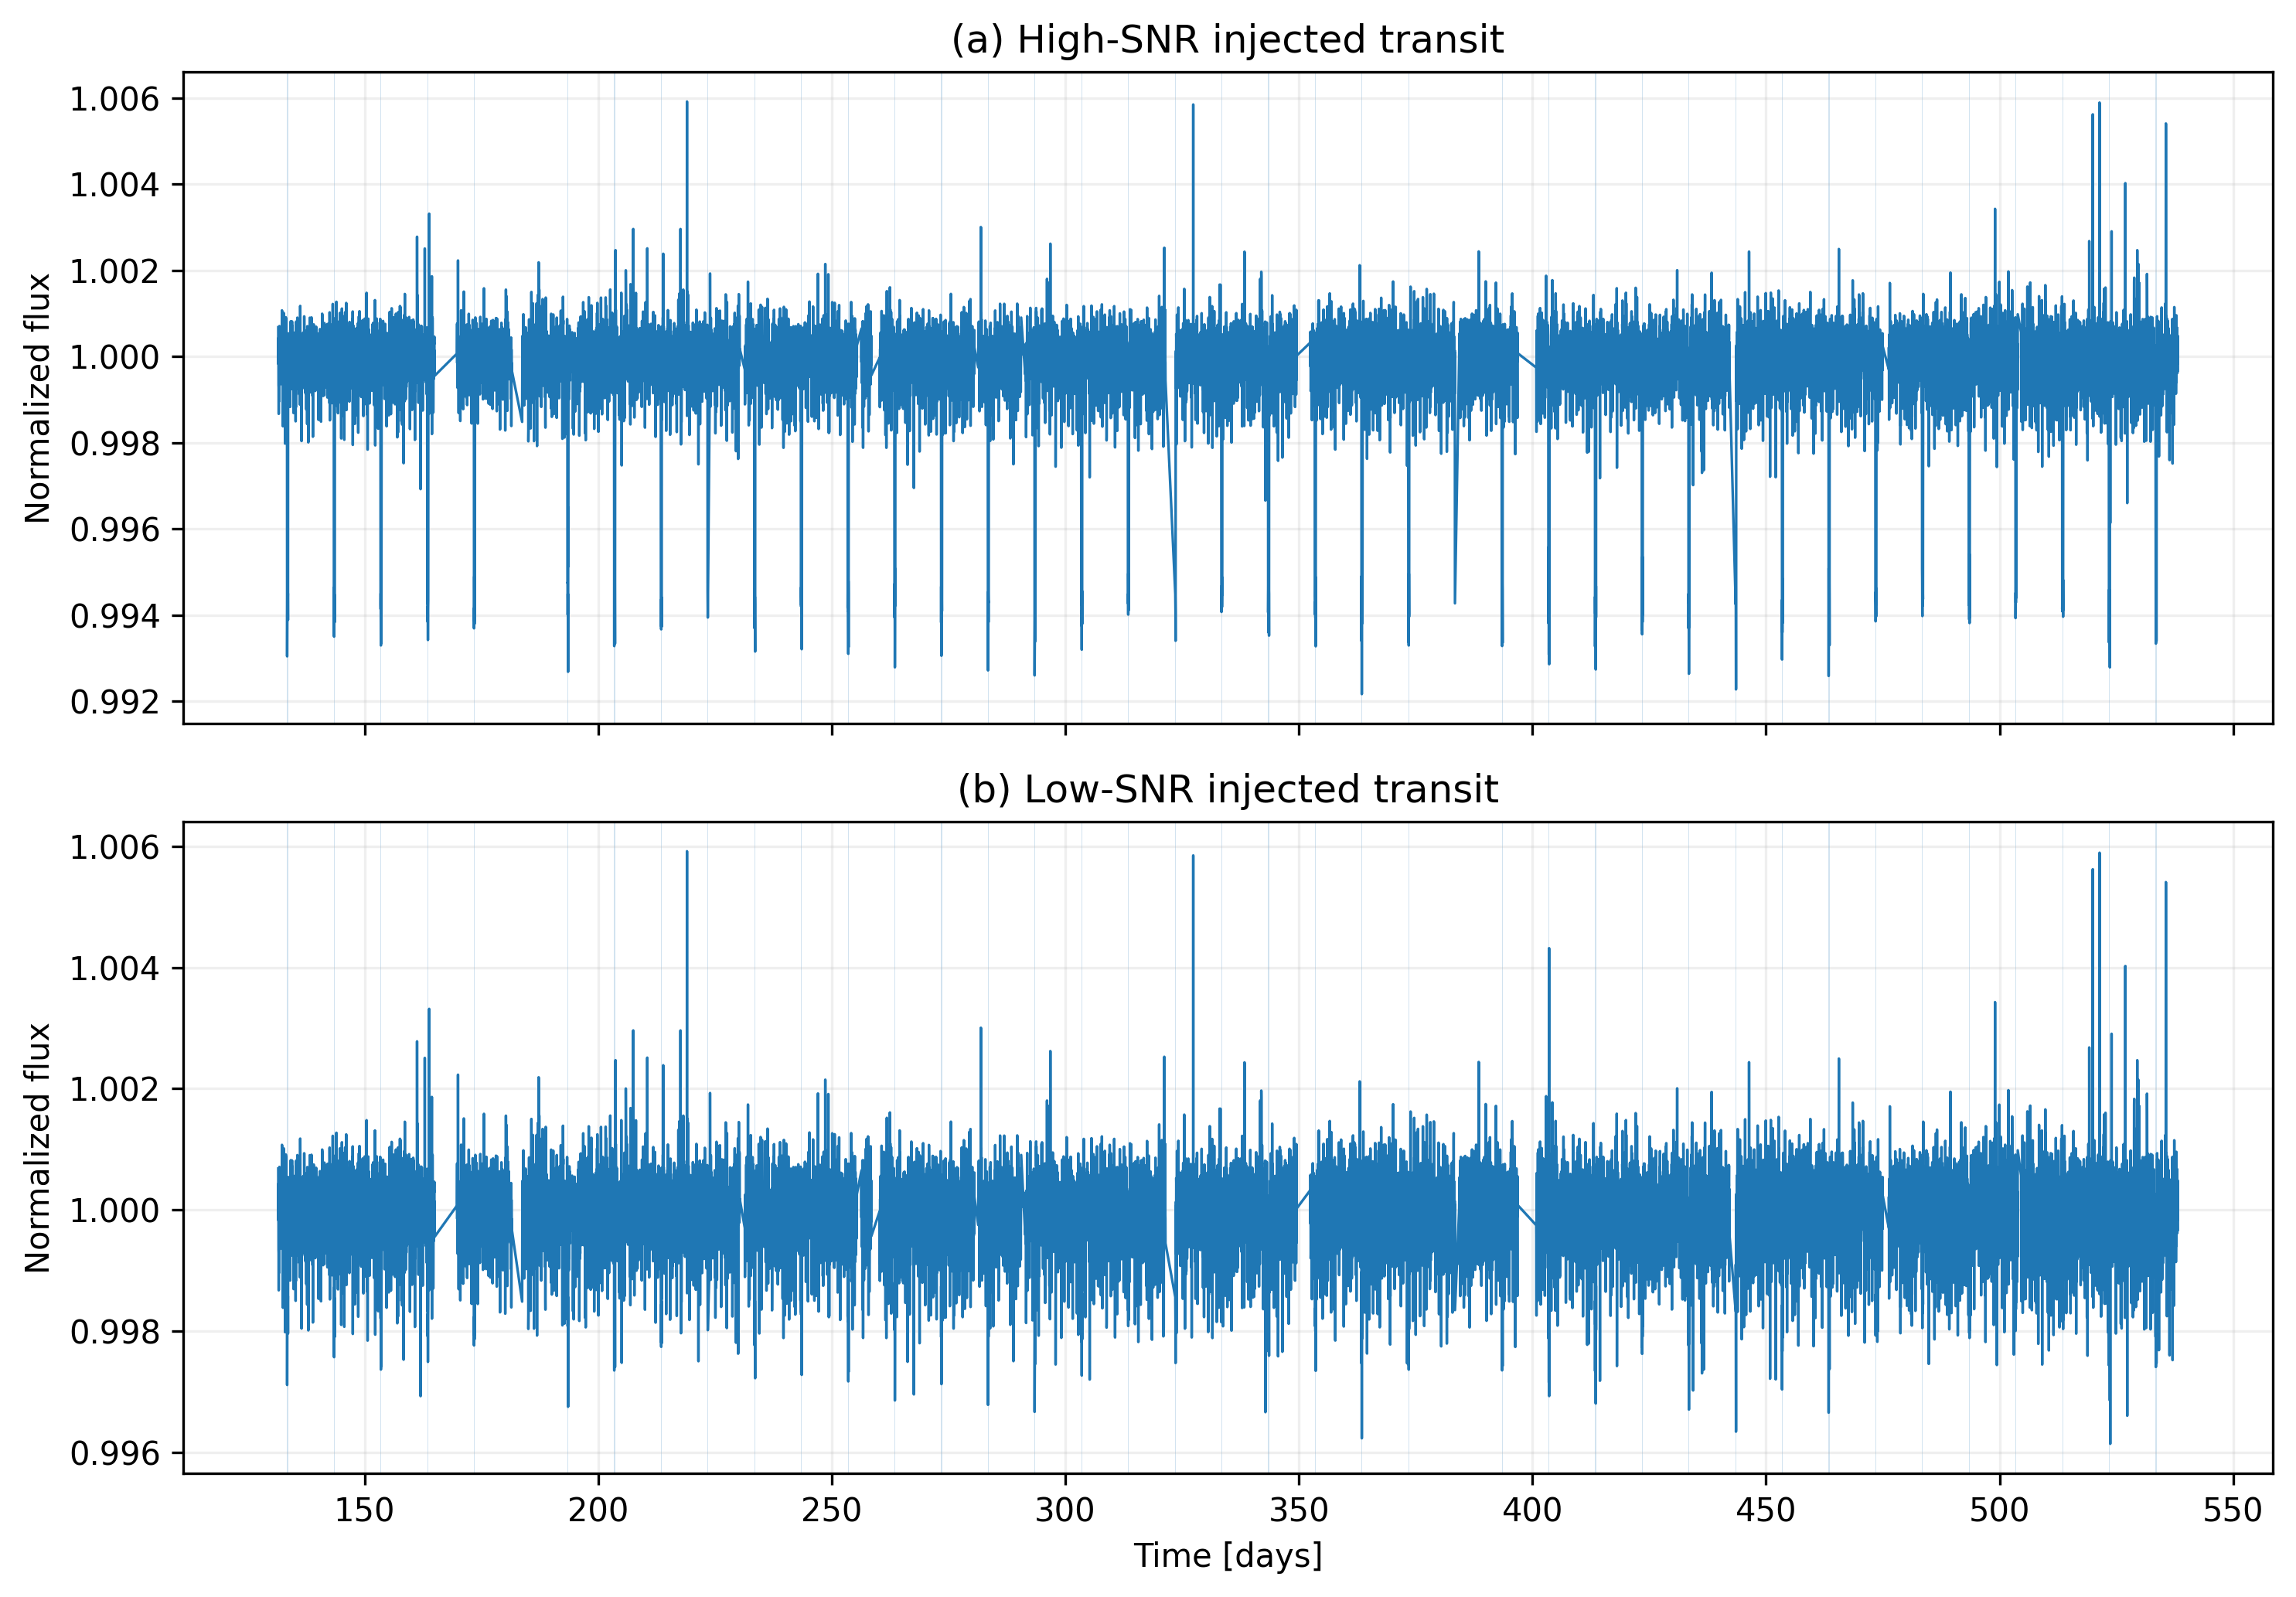

Saved: /content/figures/figure_5_2_windows.png bytes: 531023


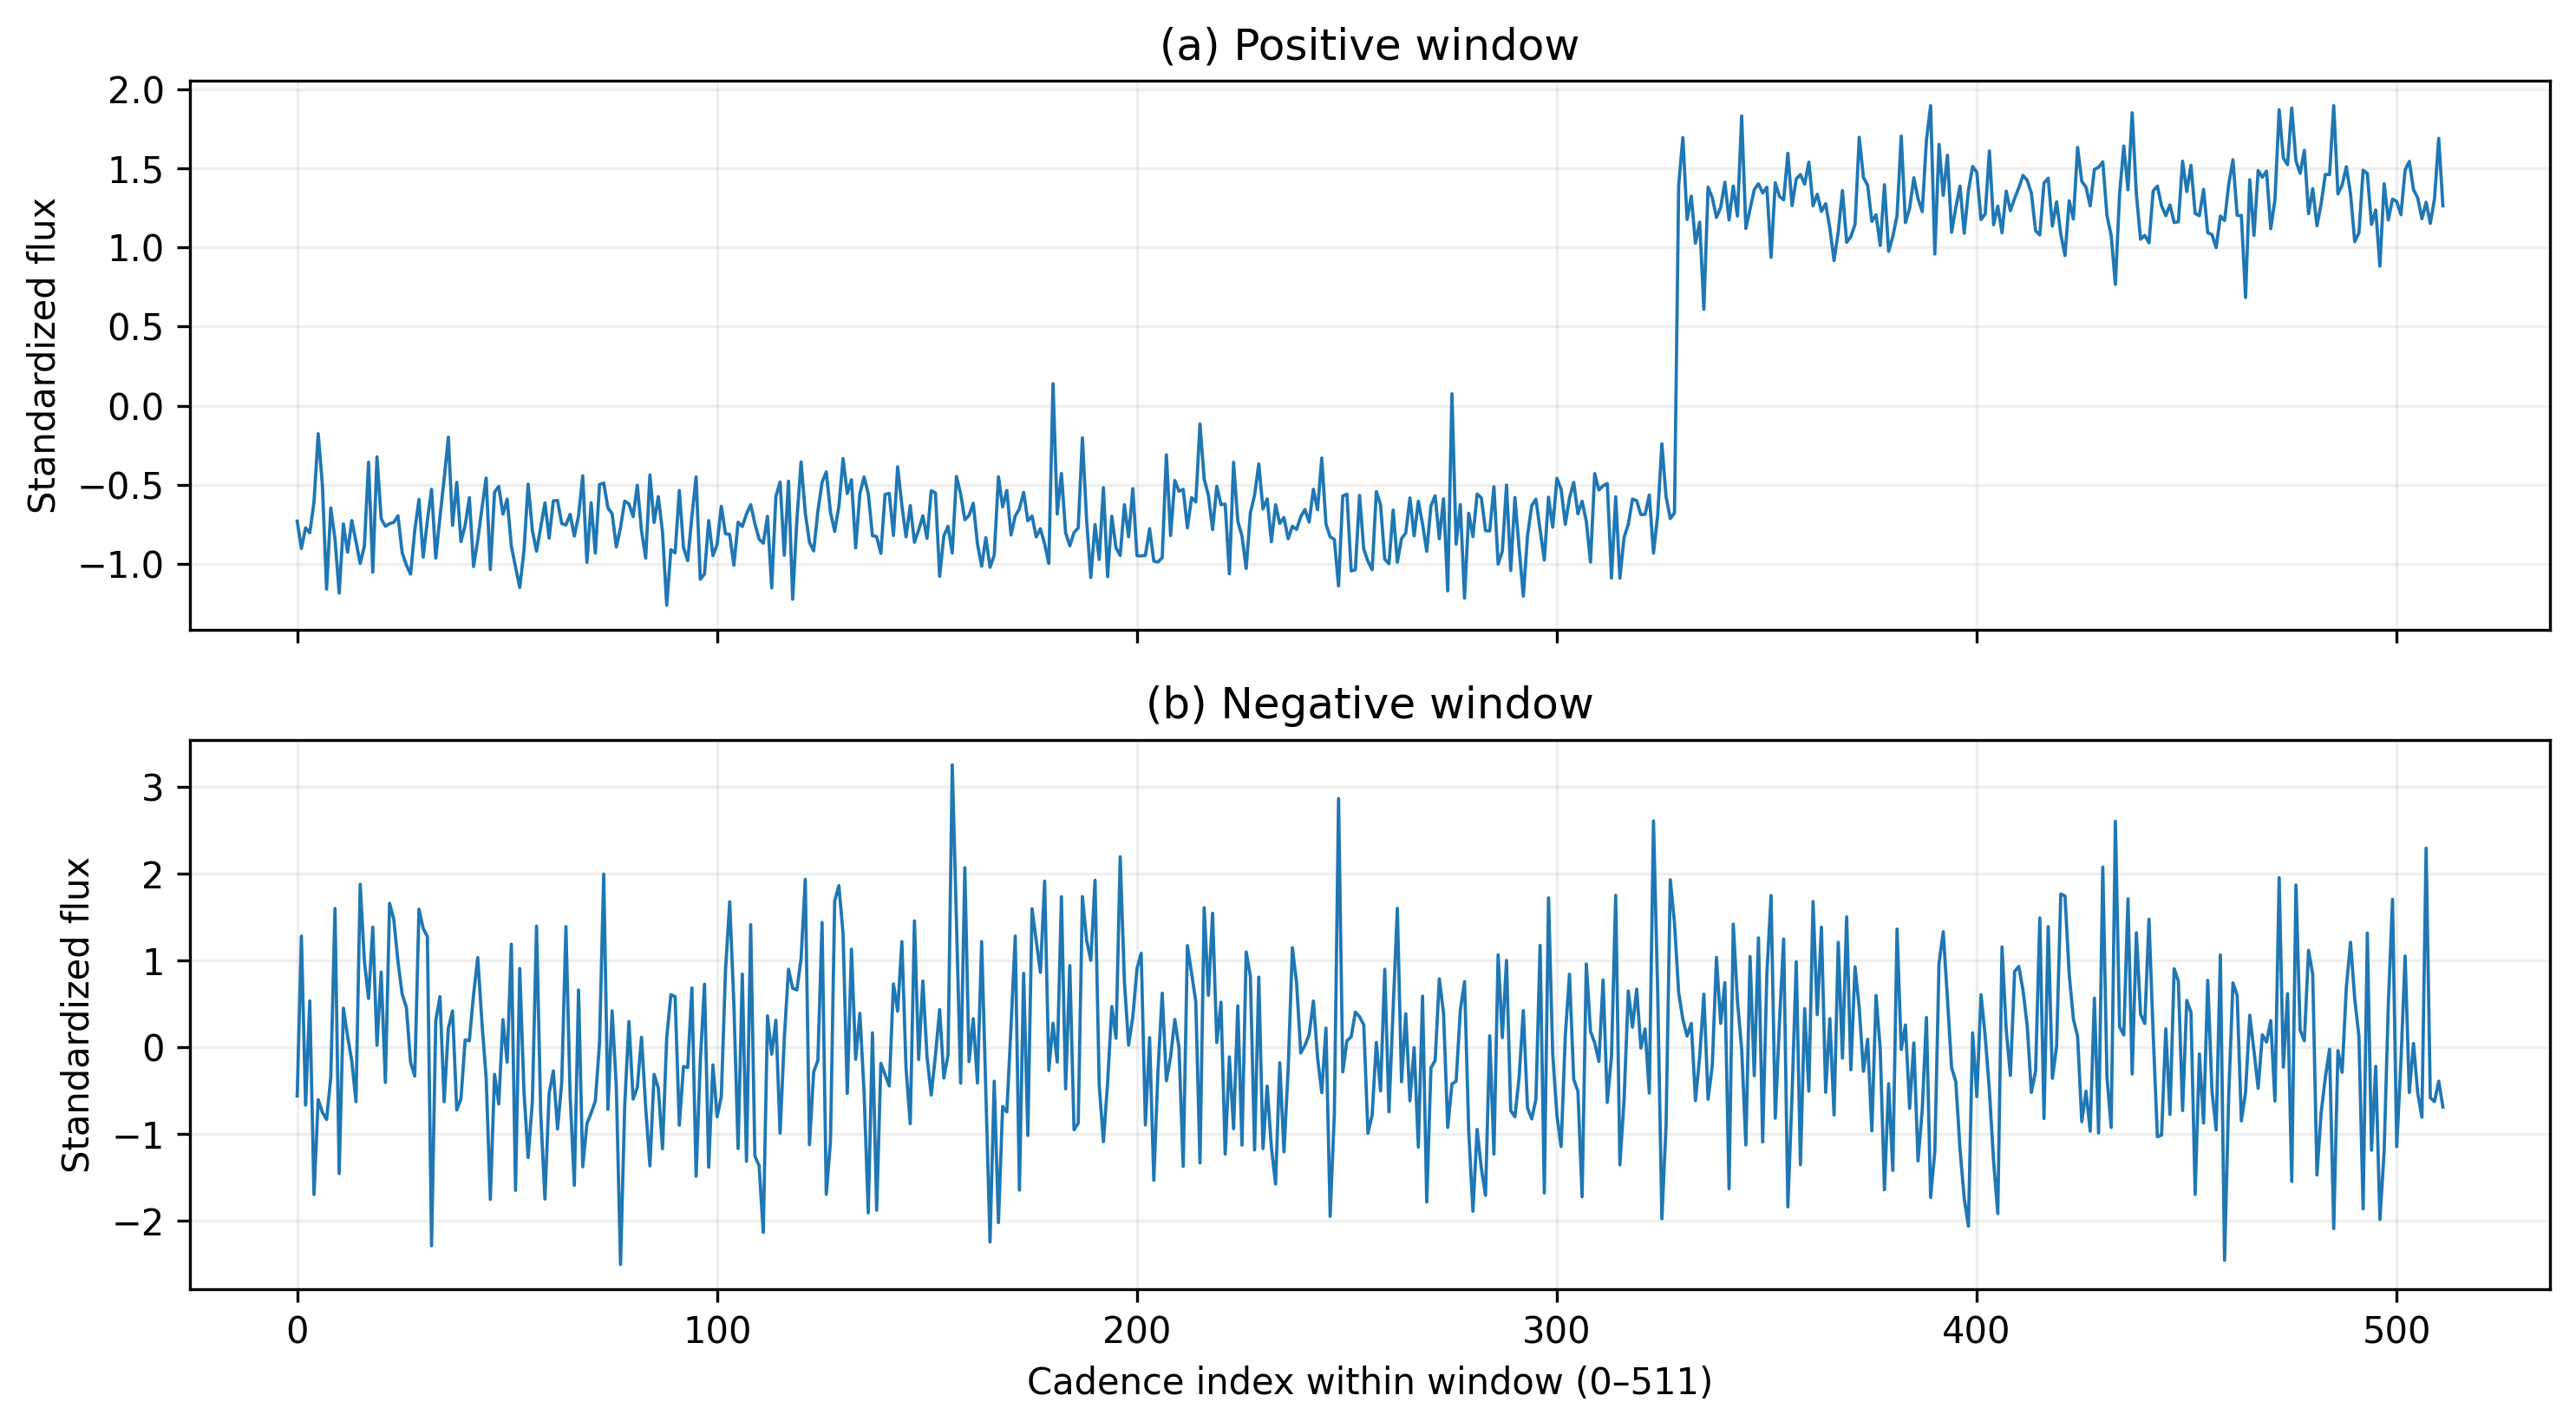

In [ ]:
from pathlib import Path
from PIL import Image
from IPython.display import display

# Save directory (Colab-friendly)
outdir = Path("/content/figures")
outdir.mkdir(parents=True, exist_ok=True)

# -------------------------
# Helper: shade in-transit
# -------------------------
def shade_in_transit(ax, time, mask, alpha=0.2):
    if mask is None:
        return
    m = np.asarray(mask, dtype=bool)
    if not m.any():
        return
    edges = np.diff(m.astype(int))
    starts = np.where(edges == 1)[0] + 1
    ends   = np.where(edges == -1)[0] + 1
    if m[0]:
        starts = np.r_[0, starts]
    if m[-1]:
        ends = np.r_[ends, len(m)]
    for s, e in zip(starts, ends):
        ax.axvspan(time[s], time[e-1], alpha=alpha)

# =========================
# FIGURE 5.1: light curves
# =========================
fig_lc, axes = plt.subplots(2, 1, figsize=(10, 7), sharex=True)

axes[0].plot(time, flux_inj_high, lw=0.8)
shade_in_transit(axes[0], time, mask_in_ex)
axes[0].set_title("(a) High-SNR injected transit")
axes[0].set_ylabel("Normalized flux")
axes[0].grid(True, alpha=0.2)

axes[1].plot(time, flux_inj_low, lw=0.8)
shade_in_transit(axes[1], time, mask_in_ex)
axes[1].set_title("(b) Low-SNR injected transit")
axes[1].set_xlabel("Time [days]")
axes[1].set_ylabel("Normalized flux")
axes[1].grid(True, alpha=0.2)

fig_lc.tight_layout()

# IMPORTANT: force draw BEFORE saving
fig_lc.canvas.draw()

path_lc = outdir / "figure_5_1_lightcurves.png"
fig_lc.savefig(path_lc, dpi=300, bbox_inches="tight")
plt.close(fig_lc)  # avoid backend weirdness

# Verify saved file is non-empty and display it
print("Saved:", path_lc, "bytes:", path_lc.stat().st_size)
display(Image.open(path_lc))

# =========================
# FIGURE 5.2: window panels
# =========================
# Pick exactly one positive and one negative from validation
X = np.asarray(X_va)
y = np.asarray(y_va).astype(int)

if X.ndim == 3 and X.shape[-1] == 1:
    Xp = X[:, :, 0]
else:
    Xp = X

pos_idx = np.where(y == 1)[0]
neg_idx = np.where(y == 0)[0]

i_pos = int(np.random.choice(pos_idx, 1)[0])
i_neg = int(np.random.choice(neg_idx, 1)[0])

fig_w, axes = plt.subplots(2, 1, figsize=(10, 5.6), sharex=True)

axes[0].plot(np.arange(Xp.shape[1]), Xp[i_pos], lw=0.9)
axes[0].set_title("(a) Positive window")
axes[0].set_ylabel("Standardized flux")
axes[0].grid(True, alpha=0.2)

axes[1].plot(np.arange(Xp.shape[1]), Xp[i_neg], lw=0.9)
axes[1].set_title("(b) Negative window")
axes[1].set_xlabel("Cadence index within window (0–511)")
axes[1].set_ylabel("Standardized flux")
axes[1].grid(True, alpha=0.2)

fig_w.tight_layout()
fig_w.canvas.draw()

path_w = outdir / "figure_5_2_windows.png"
fig_w.savefig(path_w, dpi=300, bbox_inches="tight")
plt.close(fig_w)

print("Saved:", path_w, "bytes:", path_w.stat().st_size)
display(Image.open(path_w))
